In [1]:
import numpy as np
import scipy.io as sio
import vtk
from scipy.interpolate import interp1d
from vtk.util.numpy_support import numpy_to_vtk
from renderizer import EGMRenderer
import os
import cv2
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
#model_path = "/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/pruebas interpol/egm_names_all.mat"
model_path="/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/pruebas interpol/egm_names_all.mat"
geom_path = "/home/pdi/miriamgf/tesis/Autoencoders/geometries/Atria_geom/Modelos_computacionales_Carlos_Fambuena/Atria.mat"
geom_path= "/home/pdi/miriamgf/tesis/Autoencoders/geometries/Atria_geom/Modelos_Edgar/Atria.mat"
model_path_database= "/home/pdi/miriamgf/tesis/Autoencoders/Data/modelLA_RSPV_CAF_150115/EGMs.mat"
output_directory = "/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200"



In [2]:
geom_path

'/home/pdi/miriamgf/tesis/Autoencoders/geometries/Atria_geom/Modelos_Edgar/Atria.mat'

In [3]:
import h5py

os.makedirs(output_directory, exist_ok=True)

# Cargar datos del modelo y la geometría
try:
    model = sio.loadmat(model_path)["modelLA_RSPV_CAF_150115"]
except:
    try:
        with h5py.File(model_path, 'r') as f:
            model = {key: f[key][()] for key in f.keys()}
    except OSError as e:
        print(f"Error loading model file: {e}")
        model = None

try:
    geom = sio.loadmat(geom_path)["geometries"]
except:
    geom = sio.loadmat(geom_path)

In [4]:
geom

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Tue May 31 11:18:48 2022',
 '__version__': '1.0',
 '__globals__': [],
 'faces': array([[1132, 1042, 1040],
        [1042,  867,  990],
        [ 996, 1015,  935],
        ...,
        [1312, 2048, 1374],
        [1283, 2048, 1312],
        [1255, 2048, 1283]], dtype=uint16),
 'nodetype': array(['A     ', 'A     ', 'A     ', ..., 'HOLE  ', 'HOLE  ', 'HOLE  '],
       dtype='<U6'),
 'vertices': array([[ 0.23445419,  0.77122351, 32.97413277],
        [ 0.24312411,  0.68871883, 32.33604688],
        [ 0.66533786,  1.15109576, 33.23533027],
        ...,
        [-3.06883981,  7.378711  , 30.07571996],
        [ 1.88046139,  4.89190189, 32.68859025],
        [ 1.36697939, 10.9565777 , 33.26401255]])}

In [5]:
# Extraer datos
egm_tensor = model["egm"]#[0, 0]
AF_models = model["AF_models"]#[0, 0]
names=model["all_model_names"]#[0, 0]
try:
    heart = geom["heart"]
except:
    heart = geom
faces = heart["faces"][0, 0] - 1  # Convertir a índice base 0
vertices = heart["vertices"][0, 0]

if len(vertices.shape) == 0:
    faces = heart["faces"] - 1  # Convertir a índice base 0
    vertices = heart["vertices"]
    

In [6]:

print("vertices shape", vertices.shape)

vertices shape (2048, 3)


In [7]:

patient_names_list = []
patient_egm_list = []
for patient in np.unique(AF_models):
    print('patient:', patient)
    patient_indices = np.where(AF_models == patient)[0]
    patient_name = names[patient]
    patient_egm = egm_tensor[patient_indices]
    a=int(len(patient_egm)/10)
    print(a)
    patient_egm = patient_egm[0: a-1, :] #repeated N times (N confussion matrices)
    patient_names_list.append(patient_name)
    patient_egm_list.append(patient_egm)

    print(len(patient_egm), patient_name)
#Create a DataFrame from the synchronized data
df = pd.DataFrame({
    "name": patient_names_list,
    "egm": patient_egm_list
})

df.head()

patient: 0
2001
2000 b'Simulation_01_200316_001_  7'
patient: 1
4501
4500 b'Simulation_01_200212_001_  2'
patient: 2
1500
1499 b'Simulation_01_210209_001_002'
patient: 3
1500
1499 b'Simulation_01_210205_001_002'
patient: 4
2499
2498 b'LA_RSPV_CAF_150115'
patient: 5
1301
1300 b'Simulation_01_200428_001_001'
patient: 6
2001
2000 b'Simulation_01_200316_001_  5'
patient: 7
4501
4500 b'Simulation_01_191001_001_002'
patient: 8
2001
2000 b'Simulation_01_200428_001_005'
patient: 9
4501
4500 b'Simulation_01_190717_001_001'
patient: 10
2001
2000 b'Simulation_01_200212_001_  7'
patient: 11
4501
4500 b'Simulation_01_191001_001_007'
patient: 12
2000
1999 b'LA_RSPV_150113'
patient: 13
1000
999 b'Simulation_01_210119_001_001'
patient: 14
1500
1499 b'Simulation_01_210205_001_003'
patient: 15
1000
999 b'LA_PLAW_140612'
patient: 16
4501
4500 b'Simulation_01_190717_001_004'
patient: 17
1500
1499 b'Simulation_01_201223_001_002'
patient: 18
2001
2000 b'Simulation_01_200212_001_  1'
patient: 19
2000
1999 b'

,name,egm
0,b'Simulation_01_200316_001_ 7',"[[-1.1212532302092453, -0.33517611761913646, -..."
1,b'Simulation_01_200212_001_ 2',"[[-4.369828892849869, -8.415877965062302, -15...."
2,b'Simulation_01_210209_001_002',"[[-0.9870209081676146, -0.6564017500845242, -1..."
3,b'Simulation_01_210205_001_002',"[[-1.7652367977975558, -1.3955361679873406, -1..."
4,b'LA_RSPV_CAF_150115',"[[6.141773647437317, 13.701952540538946, 21.53..."


frame (600, 1600, 3) uint8


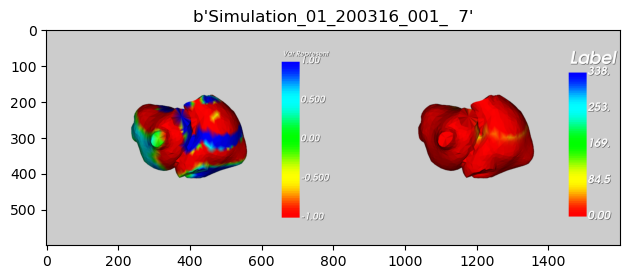

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200316_001_  7'
frame (600, 1600, 3) uint8


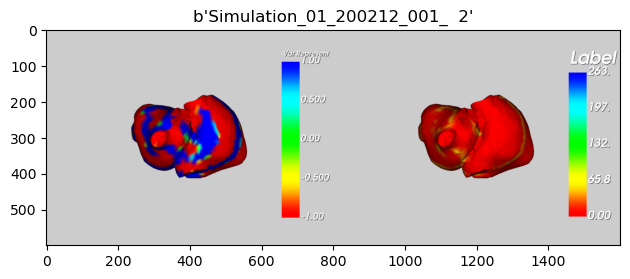

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200212_001_  2'
frame (600, 1600, 3) uint8


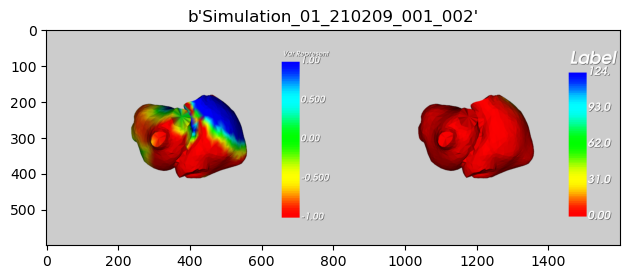

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_210209_001_002'
frame (600, 1600, 3) uint8


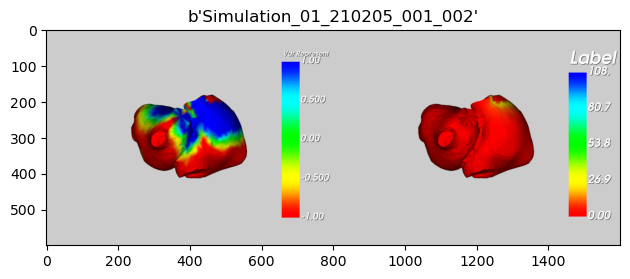

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_210205_001_002'
frame (600, 1600, 3) uint8


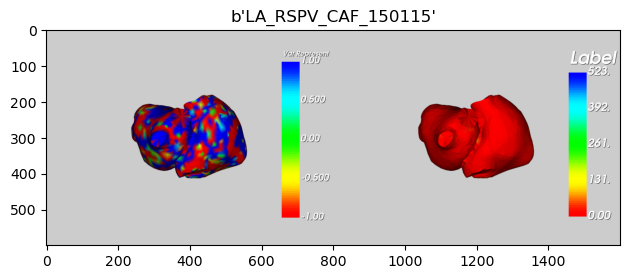

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'LA_RSPV_CAF_150115'
frame (600, 1600, 3) uint8


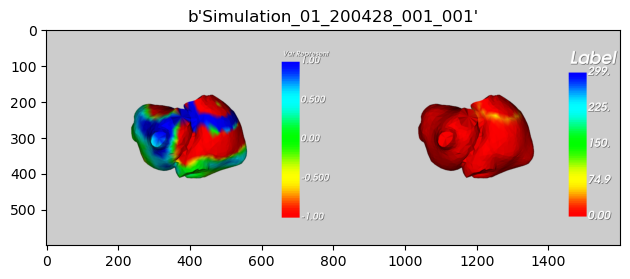

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200428_001_001'
frame (600, 1600, 3) uint8


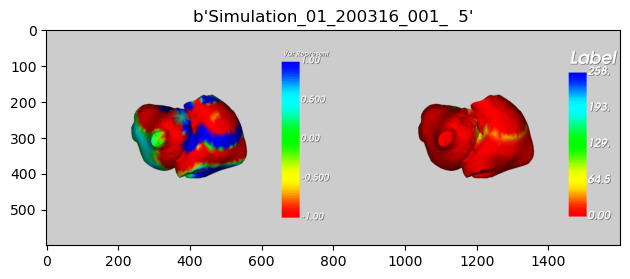

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200316_001_  5'
frame (600, 1600, 3) uint8


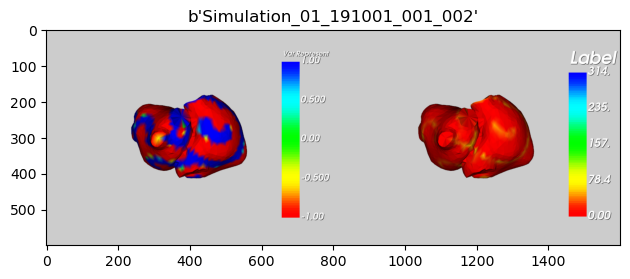

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_191001_001_002'
frame (600, 1600, 3) uint8


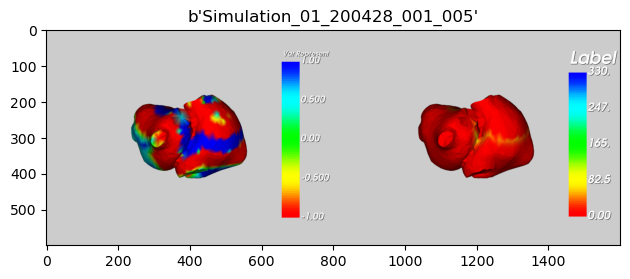

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200428_001_005'
frame (600, 1600, 3) uint8


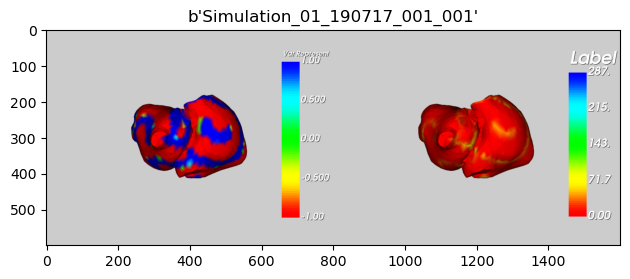

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_190717_001_001'
frame (600, 1600, 3) uint8


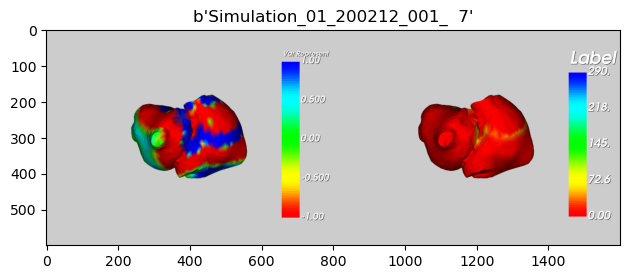

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200212_001_  7'
frame (600, 1600, 3) uint8


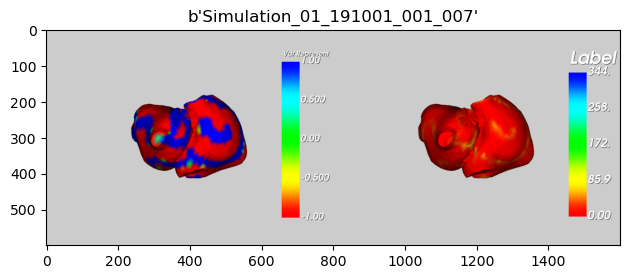

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_191001_001_007'
frame (600, 1600, 3) uint8


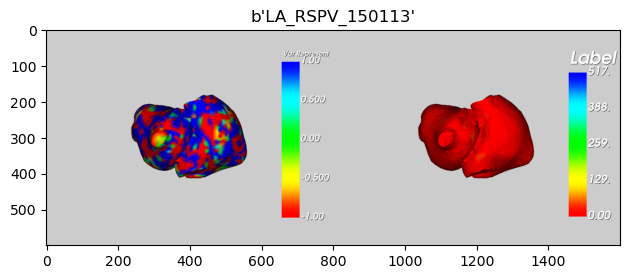

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'LA_RSPV_150113'
frame (600, 1600, 3) uint8


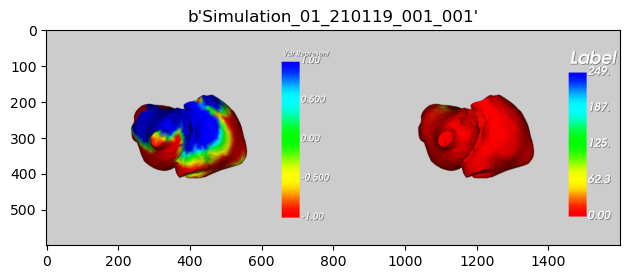

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_210119_001_001'
frame (600, 1600, 3) uint8


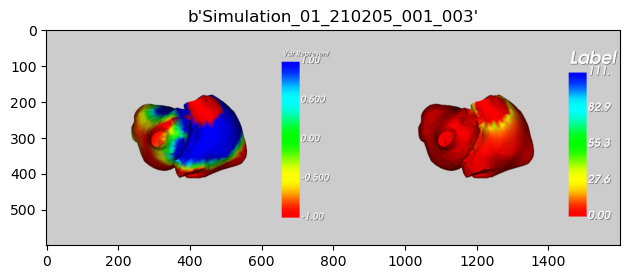

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_210205_001_003'
frame (600, 1600, 3) uint8


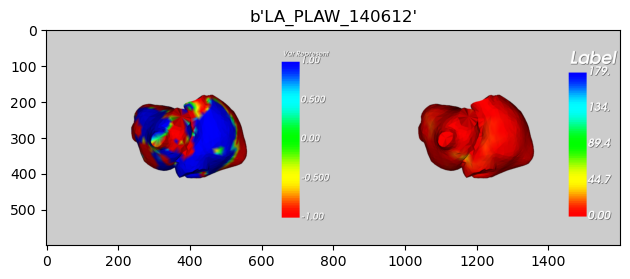

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'LA_PLAW_140612'
frame (600, 1600, 3) uint8


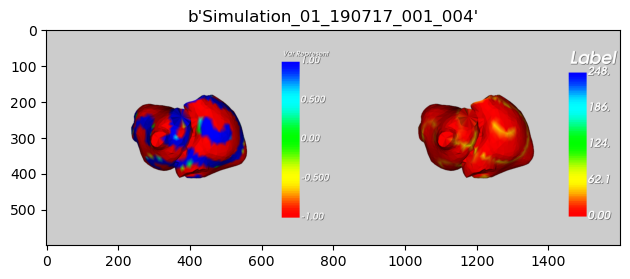

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_190717_001_004'
frame (600, 1600, 3) uint8


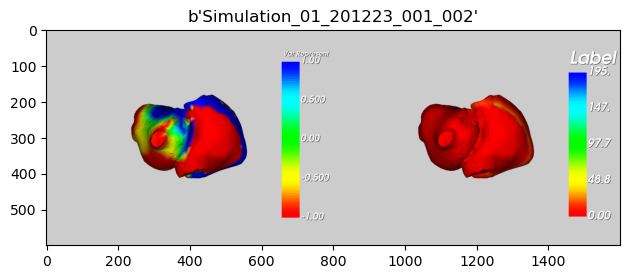

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_201223_001_002'
frame (600, 1600, 3) uint8


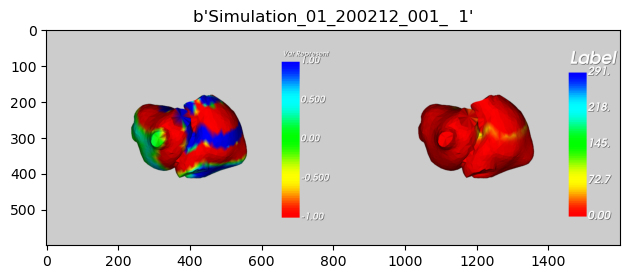

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200212_001_  1'
frame (600, 1600, 3) uint8


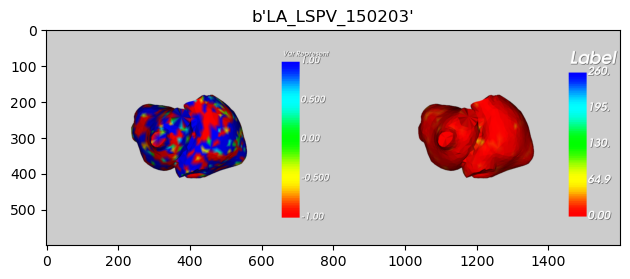

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'LA_LSPV_150203'
frame (600, 1600, 3) uint8


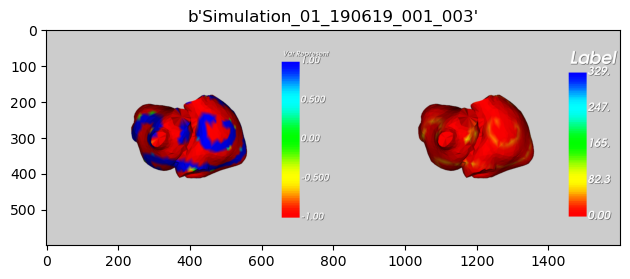

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_190619_001_003'
frame (600, 1600, 3) uint8


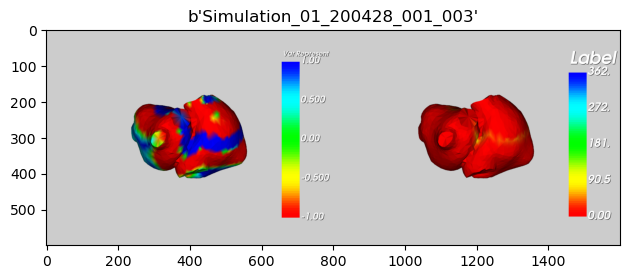

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200428_001_003'
frame (600, 1600, 3) uint8


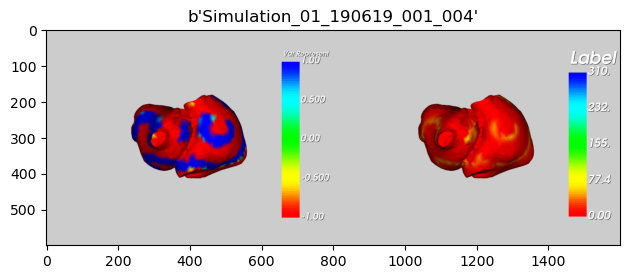

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_190619_001_004'
frame (600, 1600, 3) uint8


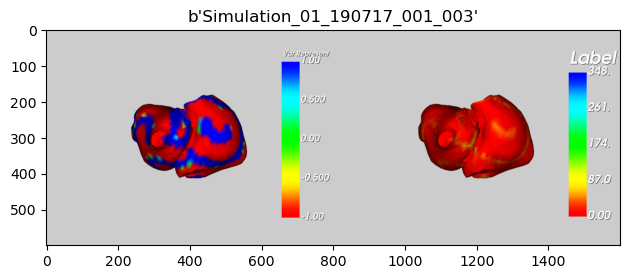

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_190717_001_003'
frame (600, 1600, 3) uint8


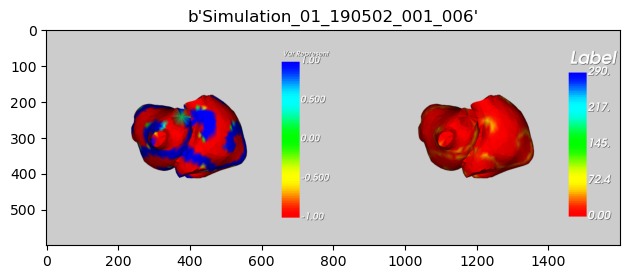

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_190502_001_006'
frame (600, 1600, 3) uint8


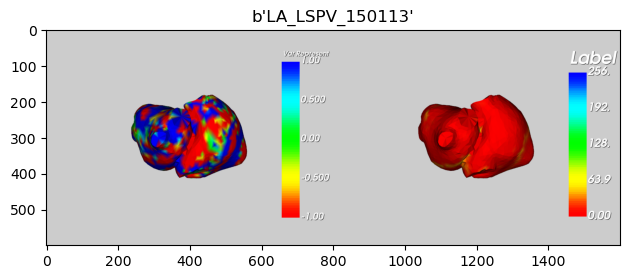

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'LA_LSPV_150113'
frame (600, 1600, 3) uint8


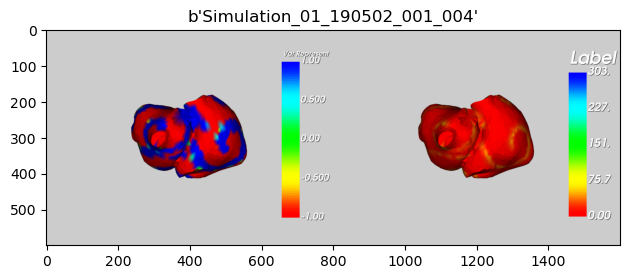

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_190502_001_004'
frame (600, 1600, 3) uint8


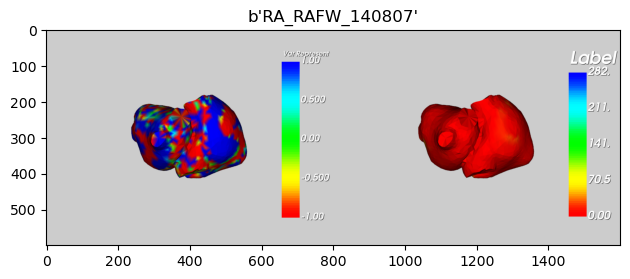

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'RA_RAFW_140807'
frame (600, 1600, 3) uint8


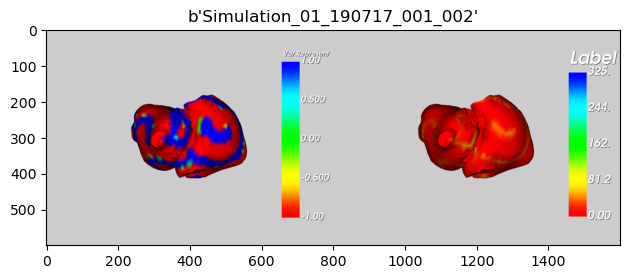

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_190717_001_002'
frame (600, 1600, 3) uint8


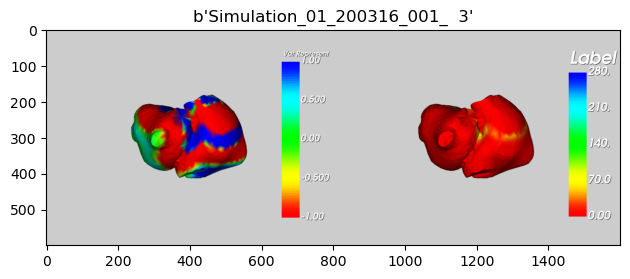

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200316_001_  3'
frame (600, 1600, 3) uint8


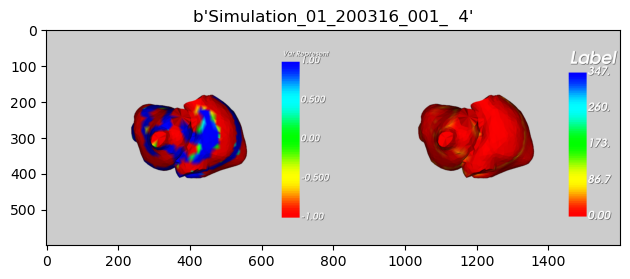

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200316_001_  4'
frame (600, 1600, 3) uint8


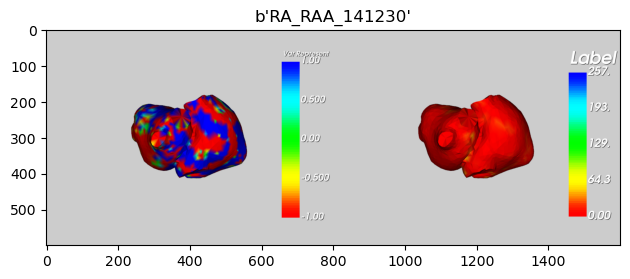

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'RA_RAA_141230'
frame (600, 1600, 3) uint8


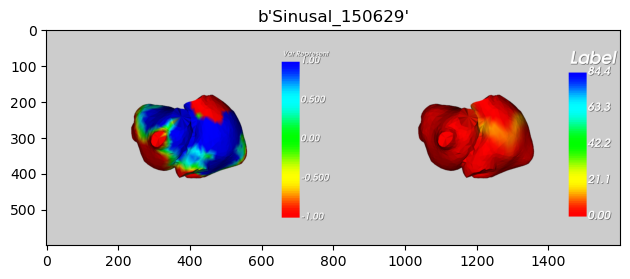

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Sinusal_150629'
frame (600, 1600, 3) uint8


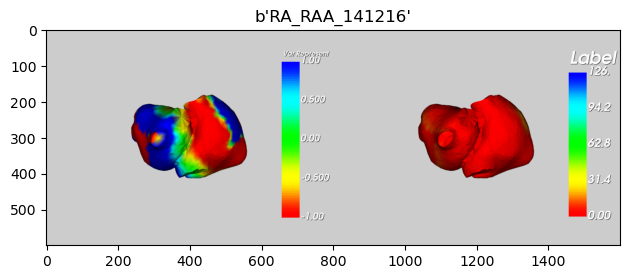

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'RA_RAA_141216'
frame (600, 1600, 3) uint8


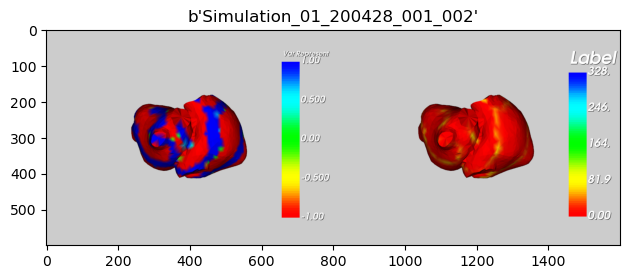

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200428_001_002'
frame (600, 1600, 3) uint8


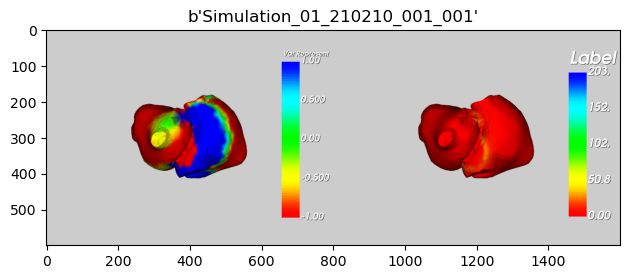

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_210210_001_001'
frame (600, 1600, 3) uint8


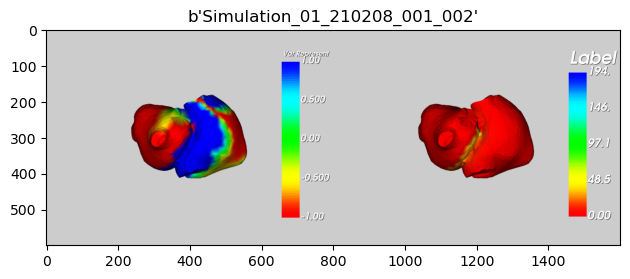

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_210208_001_002'
frame (600, 1600, 3) uint8


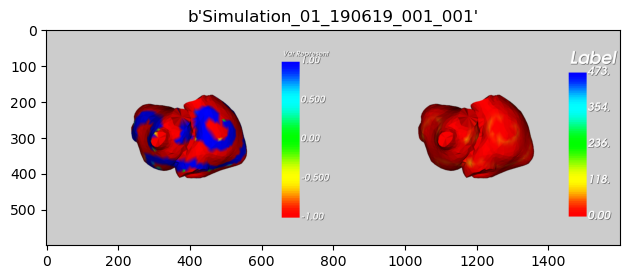

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_190619_001_001'
frame (600, 1600, 3) uint8


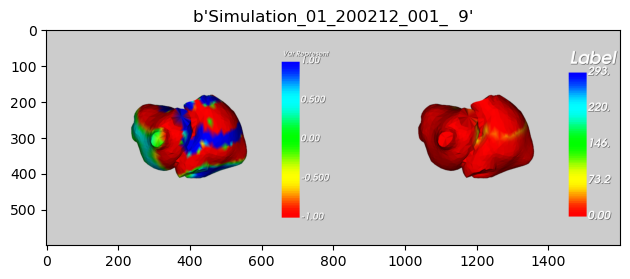

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200212_001_  9'
frame (600, 1600, 3) uint8


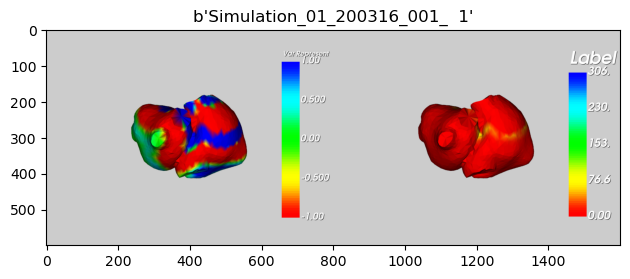

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200316_001_  1'
frame (600, 1600, 3) uint8


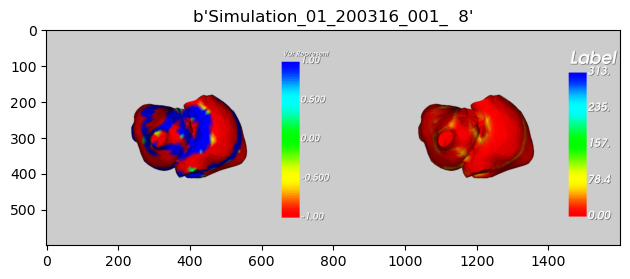

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200316_001_  8'
frame (600, 1600, 3) uint8


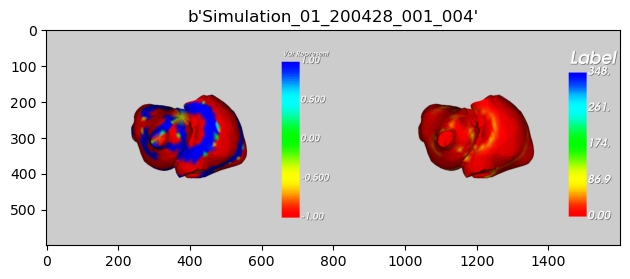

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200428_001_004'
frame (600, 1600, 3) uint8


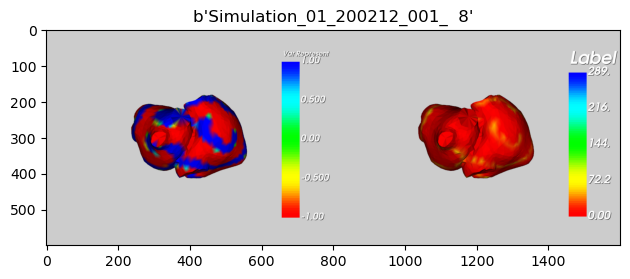

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200212_001_  8'
frame (600, 1600, 3) uint8


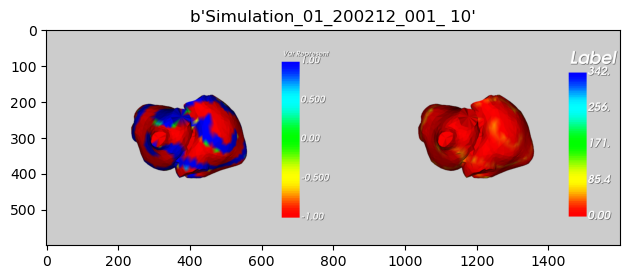

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200212_001_ 10'
frame (600, 1600, 3) uint8


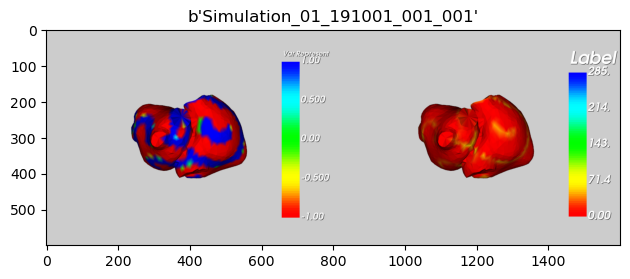

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_191001_001_001'
frame (600, 1600, 3) uint8


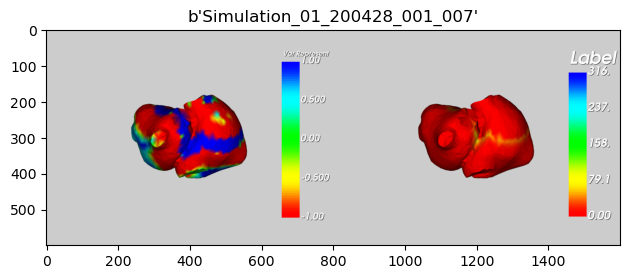

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200428_001_007'
frame (600, 1600, 3) uint8


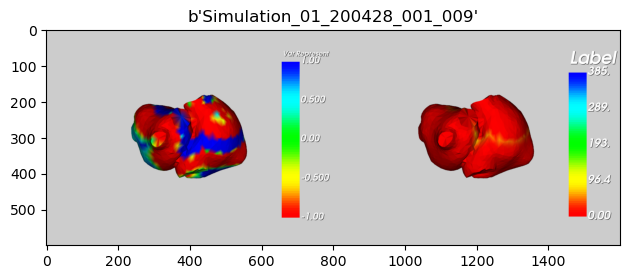

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200428_001_009'
frame (600, 1600, 3) uint8


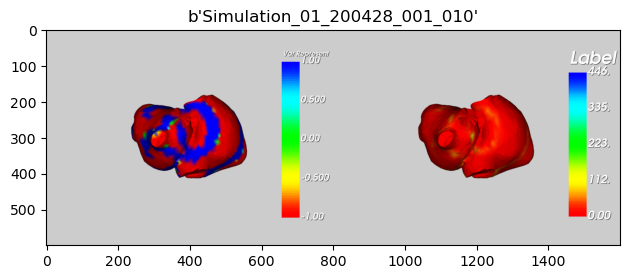

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200428_001_010'
frame (600, 1600, 3) uint8


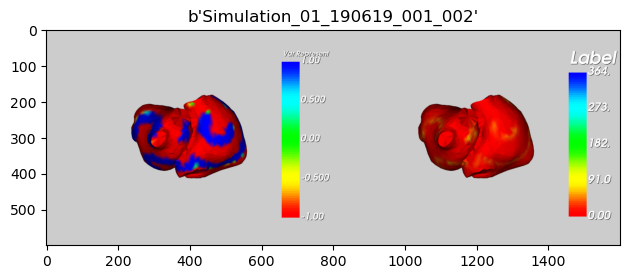

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_190619_001_002'
frame (600, 1600, 3) uint8


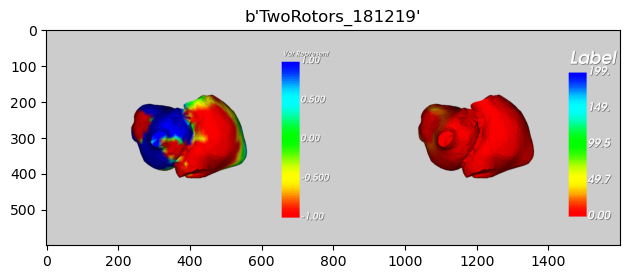

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'TwoRotors_181219'
frame (600, 1600, 3) uint8


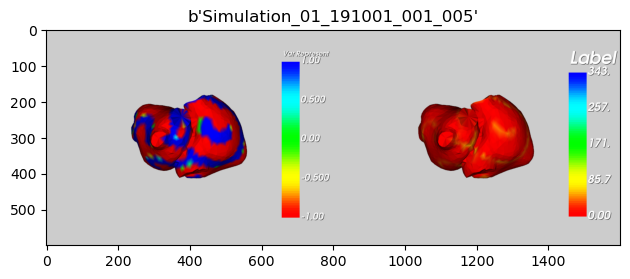

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_191001_001_005'
frame (600, 1600, 3) uint8


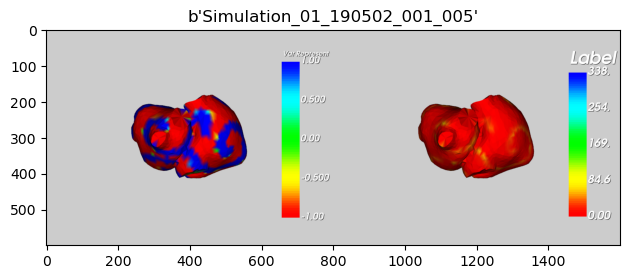

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_190502_001_005'
frame (600, 1600, 3) uint8


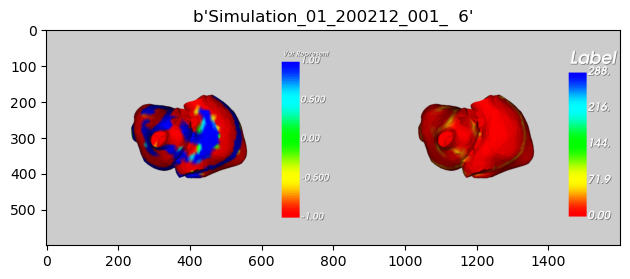

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200212_001_  6'
frame (600, 1600, 3) uint8


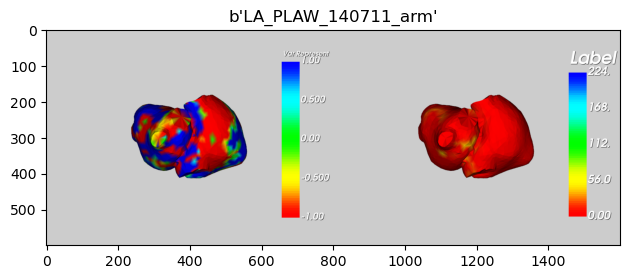

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'LA_PLAW_140711_arm'
frame (600, 1600, 3) uint8


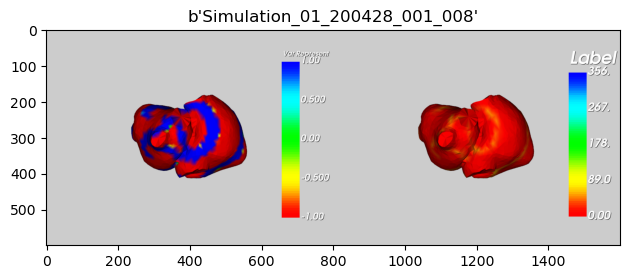

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200428_001_008'
frame (600, 1600, 3) uint8


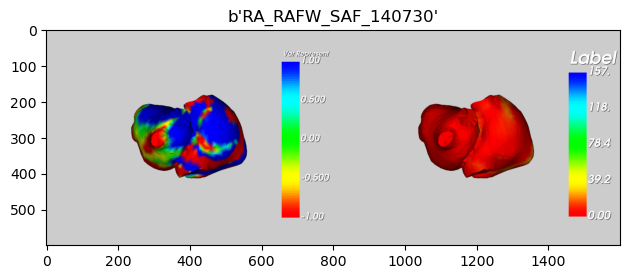

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'RA_RAFW_SAF_140730'
frame (600, 1600, 3) uint8


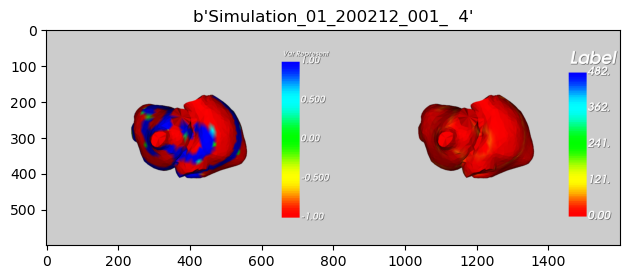

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200212_001_  4'
frame (600, 1600, 3) uint8


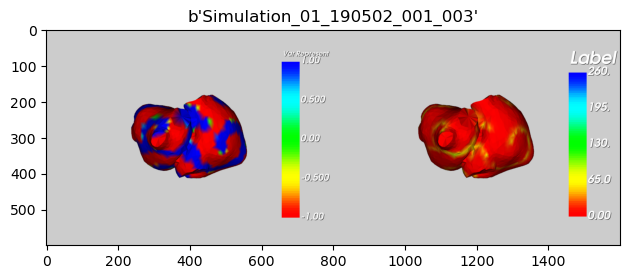

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_190502_001_003'
frame (600, 1600, 3) uint8


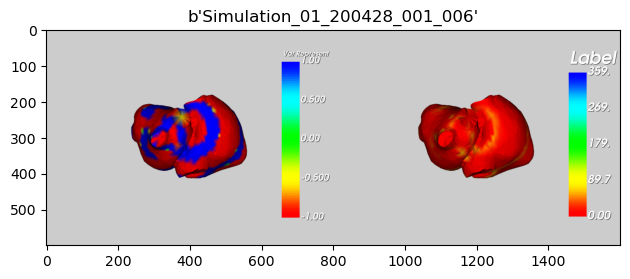

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200428_001_006'
frame (600, 1600, 3) uint8


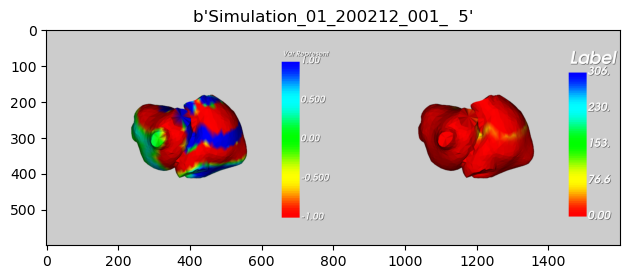

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200212_001_  5'
frame (600, 1600, 3) uint8


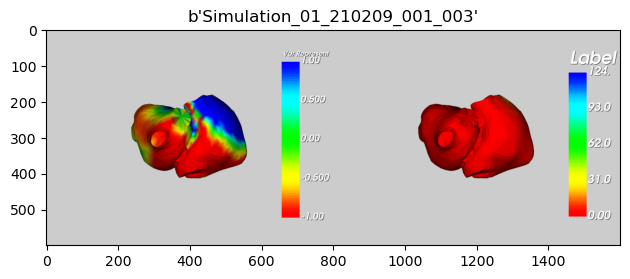

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_210209_001_003'
frame (600, 1600, 3) uint8


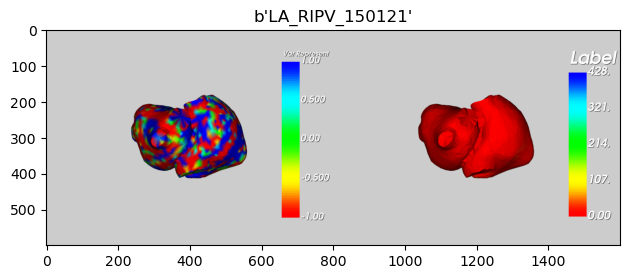

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'LA_RIPV_150121'
frame (600, 1600, 3) uint8


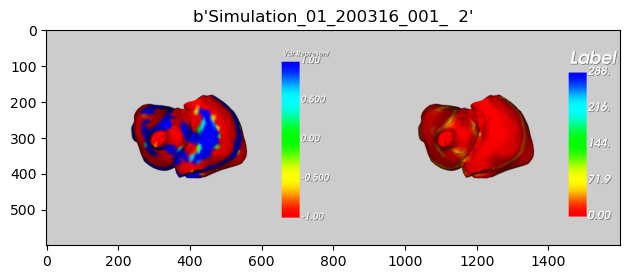

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200316_001_  2'
frame (600, 1600, 3) uint8


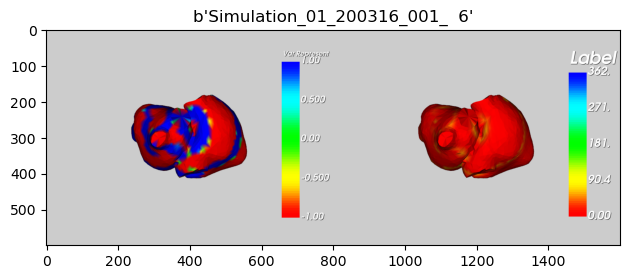

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200316_001_  6'
frame (600, 1600, 3) uint8


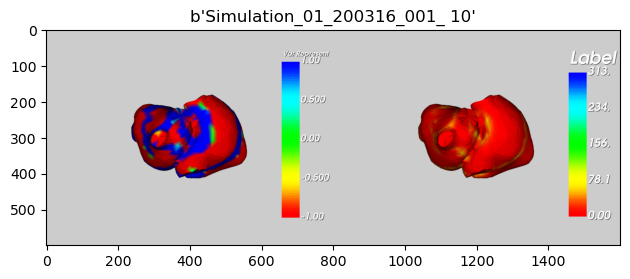

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200316_001_ 10'
frame (600, 1600, 3) uint8


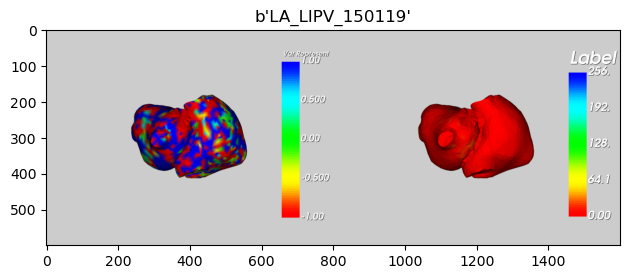

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'LA_LIPV_150119'
frame (600, 1600, 3) uint8


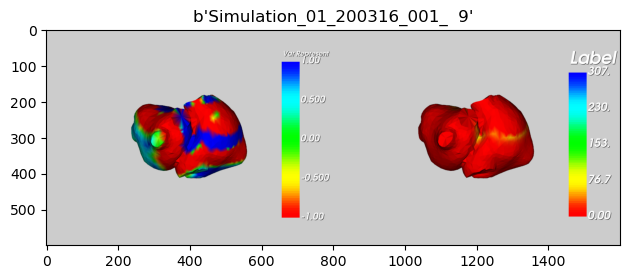

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_200316_001_  9'
frame (600, 1600, 3) uint8


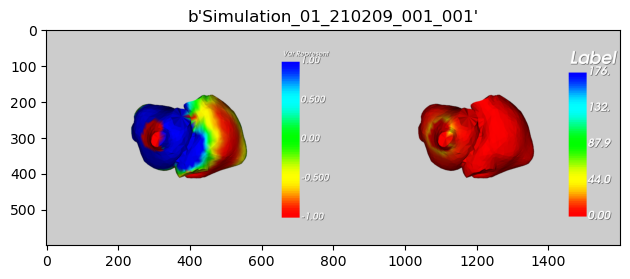

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
b'Simulation_01_210209_001_001'


In [8]:
for index, row in df.iterrows():
    # Access the name and egm for the current row
    name = row['name']
    y_reconstructed = row['egm'] 

    y_label=y_reconstructed
    # Crear renderizadores para var_represent y var_represent_original
    renderer_var = EGMRenderer(faces, vertices, min_val=-1, max_val=1)
    try:
        renderer_label = EGMRenderer(faces, vertices, min_val=0, max_val=np.max(y_label))
    except:
        y_label=y_label[0][0]
        renderer_label = EGMRenderer(faces, vertices, min_val=0, max_val=np.max(y_label))

    # Generar datos suavizados
    #label_true = sio.loadmat(model_path_database)['x'].T
    if y_reconstructed.ndim>2:
        y_reconstructed = y_reconstructed.reshape(-1, y_reconstructed.shape[2]) 
        
    #y_label=y_reconstructed #toy 

    #var_represent = renderer_var.smoothing_plot(10, y_reconstructed)
    #var_represent_original = renderer_label.smoothing_plot(10, y_label)
    var_represent=y_reconstructed
    var_represent_original=y_reconstructed

    if var_represent.shape[1]!=2048:
        var_represent=var_represent[0][0]
        var_represent_original=var_represent_original[0][0]



    # Configurar renderizadores como subplots
    renderer_var.renderer.SetViewport(0.0, 0.0, 0.5, 1.0)  # Subplot izquierdo
    renderer_label.renderer.SetViewport(0.5, 0.0, 1.0, 1.0)  # Subplot derecho

    # Configurar fondo blanco
    renderer_var.renderer.SetBackground(0.8, 0.8, 0.8)  # Gris claro
    renderer_label.renderer.SetBackground(0.8, 0.8, 0.8)  # Gris claro


    # Crear barras de color (leyendas)
    scalar_bar_var = vtk.vtkScalarBarActor()
    scalar_bar_var.SetLookupTable(renderer_var.mapper.GetLookupTable())
    scalar_bar_var.SetTitle("Var Represent")
    scalar_bar_var.SetNumberOfLabels(5)

    scalar_bar_label = vtk.vtkScalarBarActor()
    scalar_bar_label.SetLookupTable(renderer_label.mapper.GetLookupTable())
    scalar_bar_label.SetTitle("Label")
    scalar_bar_label.SetNumberOfLabels(5)

    renderer_var.renderer.AddActor2D(scalar_bar_var)
    renderer_label.renderer.AddActor2D(scalar_bar_label)

    # Configurar la ventana de renderizado conjunta
    render_window = vtk.vtkRenderWindow()
    render_window.SetSize(1600, 600)  # Tamaño total de la ventana
    render_window.AddRenderer(renderer_var.renderer)
    render_window.AddRenderer(renderer_label.renderer)

    # Configurar la cámara para ambos subplots
    center = renderer_var.mesh.GetCenter()
    for renderer in [renderer_var, renderer_label]:
        renderer.camera.SetPosition(center[0], center[1], center[2] + 50)  # Alejar la cámara
        renderer.camera.SetFocalPoint(center[0], center[1], center[2])  # Enfocar al centro
        renderer.camera.SetViewUp(1, 0, 0)  # Eje vertical hacia arriba
        renderer.camera.Elevation(270)  # Flip de 180 grados sobre el eje horizontal
        renderer.camera.Azimuth(0)  # Rotar 0 grados en azimut
        renderer.renderer.ResetCameraClippingRange()

    # Configurar el filtro para capturar imágenes
    window_to_image_filter = vtk.vtkWindowToImageFilter()
    window_to_image_filter.SetInput(render_window)

    #configure video
    output_video = os.path.join(output_directory, f"video23.avi")
    sample_frame = os.path.join(output_directory, "sample_frame.png")
    renderer.render_frame(var_represent[0, :], sample_frame)
    framei = cv2.imread(sample_frame)
    height, width, layers = framei.shape
    fps = 10  # Frames por segundo
    fourcc = cv2.VideoWriter_fourcc(*'XVID')  # Codec para AVI
    video = cv2.VideoWriter(output_video, fourcc, fps, (1600, 600))

    # Iterar sobre instantes y generar frames
    for instant in range(0, 1, 1):  # Cada 500 instantes
        # Actualizar los datos escalares de los dos renderizadores
        vtk_scalars_var = numpy_to_vtk(var_represent[instant, :], deep=True)
        vtk_scalars_label = numpy_to_vtk(var_represent_original[instant, :], deep=True)

        renderer_var.mesh.GetPointData().SetScalars(vtk_scalars_var)
        renderer_label.mesh.GetPointData().SetScalars(vtk_scalars_label)


        renderer_var.mesh.Modified()
        renderer_label.mesh.Modified()

        # Renderizar la ventana con subplots
        render_window.Render()

        # Guardar la imagen como PNG
        window_to_image_filter.Modified()
        window_to_image_filter.Update()

        output_file = os.path.join(output_directory, f"frame_{instant:04d}.png")
        writer = vtk.vtkPNGWriter()
        writer.SetFileName(output_file)
        writer.SetInputData(window_to_image_filter.GetOutput())
        writer.Write()

        # Obtener la imagen como un array numpy
        image_data = window_to_image_filter.GetOutput()
        dims = image_data.GetDimensions()
        vtk_array = vtk.util.numpy_support.vtk_to_numpy(image_data.GetPointData().GetScalars())
        frame = vtk_array.reshape((dims[1], dims[0], 3))[::-1]  # Invertir eje Y
        print('frame', frame.shape, frame.dtype)

        # Escribir el frame en el video
        video.write(frame)

        # Plot the frames
        #fig, axes = plt.subplots(5, 5, figsize=(15, 15))  # Adjust the number of rows and columns as needed
        #axes = axes.flatten()

        plt.figure()
        plt.imshow(frame)
        plt.title(name)

        plt.tight_layout()
        plt.show()

        print(f"Frame guardado: {output_file}")
        print(name)
        #os.remove(output_file)

    # Liberar el objeto VideoWriter
    #video.release()

    #print(f"Video guardado en {output_video}")

In [9]:
vertices

array([[ 0.23445419,  0.77122351, 32.97413277],
       [ 0.24312411,  0.68871883, 32.33604688],
       [ 0.66533786,  1.15109576, 33.23533027],
       ...,
       [-3.06883981,  7.378711  , 30.07571996],
       [ 1.88046139,  4.89190189, 32.68859025],
       [ 1.36697939, 10.9565777 , 33.26401255]])

In [10]:
df

,name,egm
0,b'Simulation_01_200316_001_ 7',"[[-1.1212532302092453, -0.33517611761913646, -..."
1,b'Simulation_01_200212_001_ 2',"[[-4.369828892849869, -8.415877965062302, -15...."
2,b'Simulation_01_210209_001_002',"[[-0.9870209081676146, -0.6564017500845242, -1..."
3,b'Simulation_01_210205_001_002',"[[-1.7652367977975558, -1.3955361679873406, -1..."
4,b'LA_RSPV_CAF_150115',"[[6.141773647437317, 13.701952540538946, 21.53..."
...,...,...
63,b'Simulation_01_200316_001_ 6',"[[-1.6791208325128548, -4.235092247419539, -7...."
64,b'Simulation_01_200316_001_ 10',"[[-2.0380232948094568, -3.311938061849803, -3...."
65,b'LA_LIPV_150119',"[[-2.5672163725222785, 0.6825518043835749, -0...."
66,b'Simulation_01_200316_001_ 9',"[[-1.4224001847903696, -0.5509359894766492, -1..."


(3999, 2048)
frame (600, 1600, 3) uint8


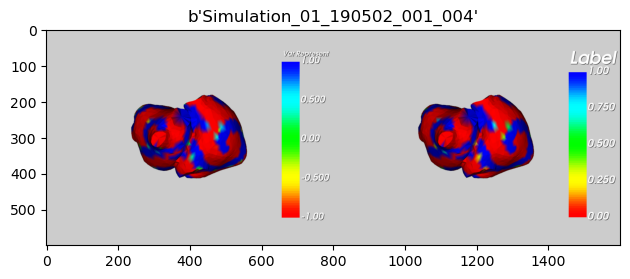

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0000.png
0
frame (600, 1600, 3) uint8


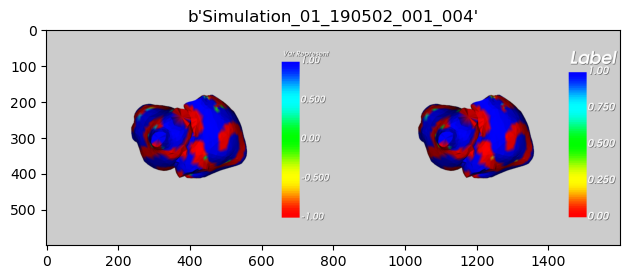

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0050.png
50
frame (600, 1600, 3) uint8


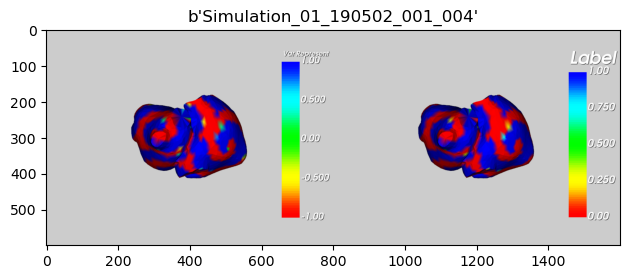

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0100.png
100
frame (600, 1600, 3) uint8


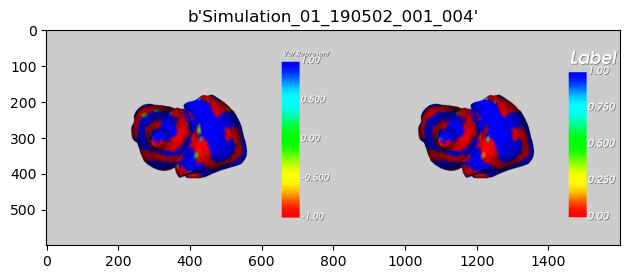

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0150.png
150
frame (600, 1600, 3) uint8


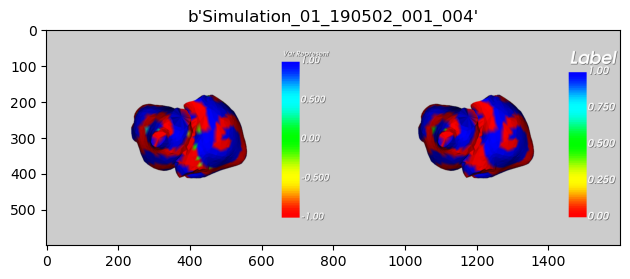

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0200.png
200
frame (600, 1600, 3) uint8


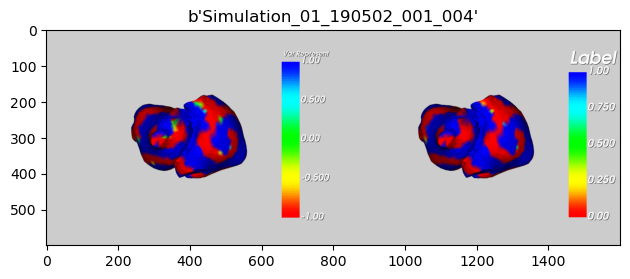

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0250.png
250
frame (600, 1600, 3) uint8


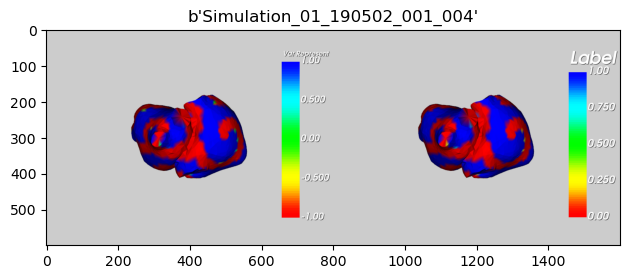

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0300.png
300
frame (600, 1600, 3) uint8


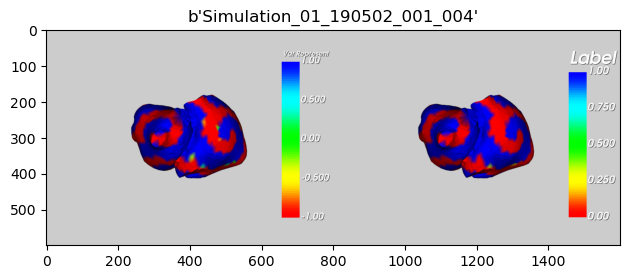

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0350.png
350
frame (600, 1600, 3) uint8


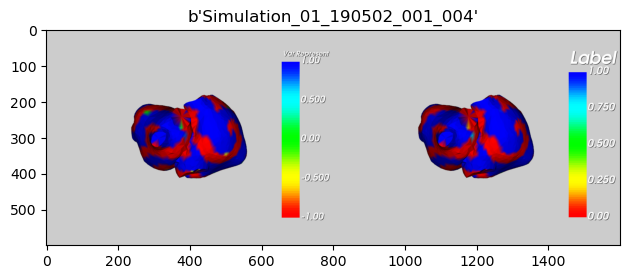

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0400.png
400
frame (600, 1600, 3) uint8


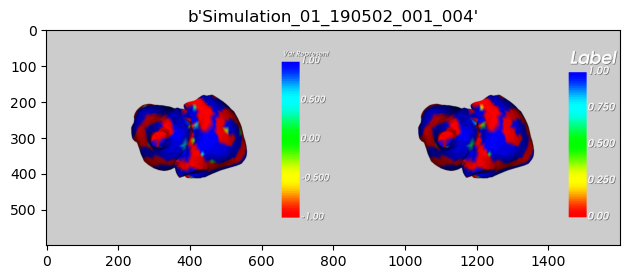

Frame guardado: /home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI_bs_200/frame_0450.png
450


In [11]:
df_filtered = df[df['name'] == b'Simulation_01_190502_001_004']
# Get the row with the desired name
row = df_filtered.iloc[0]

# Extract values from each column
name = row['name']
y_reconstructed = row['egm']

y_label=y_reconstructed
# Crear renderizadores para var_represent y var_represent_original
renderer_var = EGMRenderer(faces, vertices, min_val=-1, max_val=1)
try:
    renderer_label = EGMRenderer(faces, vertices, min_val=0, max_val=1)
except:
    y_label=y_label[0][0]
    renderer_label = EGMRenderer(faces, vertices, min_val=0, max_val=1)

# Generar datos suavizados
#label_true = sio.loadmat(model_path_database)['x'].T
if y_reconstructed.ndim>2:
    y_reconstructed = y_reconstructed.reshape(-1, y_reconstructed.shape[2]) 
    
#y_label=y_reconstructed #toy 

#var_represent = renderer_var.smoothing_plot(10, y_reconstructed)
#var_represent_original = renderer_label.smoothing_plot(10, y_label)
var_represent=y_reconstructed
var_represent_original=y_reconstructed
print(var_represent.shape)
if var_represent.shape[1]!=2048:
    var_represent=var_represent[0][0]
    var_represent_original=var_represent_original[0][0]



# Configurar renderizadores como subplots
renderer_var.renderer.SetViewport(0.0, 0.0, 0.5, 1.0)  # Subplot izquierdo
renderer_label.renderer.SetViewport(0.5, 0.0, 1.0, 1.0)  # Subplot derecho

# Configurar fondo blanco
renderer_var.renderer.SetBackground(0.8, 0.8, 0.8)  # Gris claro
renderer_label.renderer.SetBackground(0.8, 0.8, 0.8)  # Gris claro


# Crear barras de color (leyendas)
scalar_bar_var = vtk.vtkScalarBarActor()
scalar_bar_var.SetLookupTable(renderer_var.mapper.GetLookupTable())
scalar_bar_var.SetTitle("Var Represent")
scalar_bar_var.SetNumberOfLabels(5)

scalar_bar_label = vtk.vtkScalarBarActor()
scalar_bar_label.SetLookupTable(renderer_label.mapper.GetLookupTable())
scalar_bar_label.SetTitle("Label")
scalar_bar_label.SetNumberOfLabels(5)

renderer_var.renderer.AddActor2D(scalar_bar_var)
renderer_label.renderer.AddActor2D(scalar_bar_label)

# Configurar la ventana de renderizado conjunta
render_window = vtk.vtkRenderWindow()
render_window.SetSize(1600, 600)  # Tamaño total de la ventana
render_window.AddRenderer(renderer_var.renderer)
render_window.AddRenderer(renderer_label.renderer)

# Configurar la cámara para ambos subplots
center = renderer_var.mesh.GetCenter()
for renderer in [renderer_var, renderer_label]:
    renderer.camera.SetPosition(center[0], center[1], center[2] + 50)  # Alejar la cámara
    renderer.camera.SetFocalPoint(center[0], center[1], center[2])  # Enfocar al centro
    renderer.camera.SetViewUp(1, 0, 0)  # Eje vertical hacia arriba
    renderer.camera.Elevation(270)  # Flip de 180 grados sobre el eje horizontal
    renderer.camera.Azimuth(0)  # Rotar 0 grados en azimut
    renderer.renderer.ResetCameraClippingRange()

# Configurar el filtro para capturar imágenes
window_to_image_filter = vtk.vtkWindowToImageFilter()
window_to_image_filter.SetInput(render_window)

#configure video
output_video = os.path.join(output_directory, f"video23.avi")
sample_frame = os.path.join(output_directory, "sample_frame.png")
renderer.render_frame(var_represent[0, :], sample_frame)
framei = cv2.imread(sample_frame)
height, width, layers = framei.shape
fps = 10  # Frames por segundo
fourcc = cv2.VideoWriter_fourcc(*'XVID')  # Codec para AVI
video = cv2.VideoWriter(output_video, fourcc, fps, (1600, 600))

# Iterar sobre instantes y generar frames
for instant in range(0, 500, 50):  # Cada 500 instantes
    # Actualizar los datos escalares de los dos renderizadores
    vtk_scalars_var = numpy_to_vtk(var_represent[instant, :], deep=True)
    vtk_scalars_label = numpy_to_vtk(var_represent_original[instant, :], deep=True)

    renderer_var.mesh.GetPointData().SetScalars(vtk_scalars_var)
    renderer_label.mesh.GetPointData().SetScalars(vtk_scalars_label)


    renderer_var.mesh.Modified()
    renderer_label.mesh.Modified()

    # Renderizar la ventana con subplots
    render_window.Render()

    # Guardar la imagen como PNG
    window_to_image_filter.Modified()
    window_to_image_filter.Update()

    output_file = os.path.join(output_directory, f"frame_{instant:04d}.png")
    writer = vtk.vtkPNGWriter()
    writer.SetFileName(output_file)
    writer.SetInputData(window_to_image_filter.GetOutput())
    writer.Write()

    # Obtener la imagen como un array numpy
    image_data = window_to_image_filter.GetOutput()
    dims = image_data.GetDimensions()
    vtk_array = vtk.util.numpy_support.vtk_to_numpy(image_data.GetPointData().GetScalars())
    frame = vtk_array.reshape((dims[1], dims[0], 3))[::-1]  # Invertir eje Y
    print('frame', frame.shape, frame.dtype)

    # Escribir el frame en el video
    video.write(frame)

    # Plot the frames
    #fig, axes = plt.subplots(5, 5, figsize=(15, 15))  # Adjust the number of rows and columns as needed
    #axes = axes.flatten()

    plt.figure()
    plt.imshow(frame)
    plt.title(name)

    plt.tight_layout()
    plt.show()

    print(f"Frame guardado: {output_file}")
    print(instant)
    #os.remove(output_file)

# Liberar el objeto VideoWriter
#video.release()

#print(f"Video guardado en {output_video}")

In [12]:
df_filtered

,name,egm
26,b'Simulation_01_190502_001_004',"[[-6.613086213048627, -6.798084362961758, -17...."
